## Packages and functions

In [6]:
# CIL imports
from cil.framework import ImageGeometry, AcquisitionGeometry, BlockDataContainer, ImageData

# From cil.plugins import TomoPhantom
from phantominator import shepp_logan

from cil.optimisation.algorithms import FISTA

from cil.plugins.ccpi_regularisation.functions import FGP_TV

from cil.optimisation.functions import LeastSquares, BlockFunction, L2NormSquared, IndicatorBox
from cil.optimisation.utilities import callbacks

# For display
from cil.utilities.display import show2D, show1D, show_geometry

# ASTRA imports
from cil.plugins.astra.operators import ProjectionOperator

from cil.optimisation.algorithms import CGLS, GD

# External imports
import numpy as np
import matplotlib.pyplot as plt
import logging

from cil.optimisation.operators import BlockOperator, DiagonalOperator, GradientOperator, \
                                        CompositionOperator, ZeroOperator, MaskOperator


def get_A(n_angles, n_pixels):

    # Angles
    angles = np.linspace(0, 180, n_angles, endpoint=False, dtype=np.float32)

    # Setup acquisition geometry

    # Note that if number of pixels and number of angels are equal, 
    # the matrix is square and an exact solution can be found, 
    # then there is a sufficient number of pojections
    ag = AcquisitionGeometry.create_Parallel2D()\
                                .set_angles(angles)\
                                .set_panel(n_pixels, pixel_size=1/n_pixels)

    # Setup image geometry
    ig = ImageGeometry(voxel_num_x=n_pixels, 
                    voxel_num_y=n_pixels, 
                    voxel_size_x=1/n_pixels, 
                    voxel_size_y=1/n_pixels)
    
    A = ProjectionOperator(ig, ag, device='cpu')

    # Get phantom
    phantom = ImageData(np.flip(shepp_logan(n_pixels)), geometry = ig)

    # Create an acquisition data (numerically)
    sino = A.direct(phantom)

    return A, sino, ig, ag, phantom


def add_poss_noise(background_counts, n_angles, n_pixels):
    A, sino, ig, ag, phantom = get_A(n_angles, n_pixels)

    # adding noise to the sinogram

    # Convert the simulated absorption sinogram to transmission values using Lambert-Beer. 
    counts_poss = background_counts * np.exp(-sino.as_array())

    # Use as a mean for Poisson data generation.
    noisy_counts_poss = np.random.poisson(counts_poss)
    nonzero = noisy_counts_poss > 0

    # Convert back to absorption sinogram.
    sino_out_poss = np.zeros_like(sino.as_array())
    sino_out_poss[nonzero] = -np.log(noisy_counts_poss[nonzero]/ background_counts)

    # allocate sino_noisy and fill with noisy data
    sino_noisy_poss = ag.allocate()
    sino_noisy_poss.fill(sino_out_poss)

    return sino_noisy_poss


def onenorm_cgls(initial, inner_iter, outer_iter, A, sino, alpha, er):

    """
    Function that minimises the cost function 

    J(u) = ||Ru - b||_2^2 + ||u||_1

    by minimising 

    J(u) = ||Ru - b||_2^2 + ||W_k u||_2^2

    via the BlockFramework and the cgls function from CIL. the matrix W_k is reweighted in each iteration
    with W_k = u_k**(-1/2)

    Input
        Initial:    initial guess for u (ImageData)
        inner_iter: maximum number of iterations for cgls (integer)
        outer_iter: maximum number of iterations to reweight W_k (integer)
        A:          operator R (ProjectionOperator)
        sino:       lhs of the data fidelity term, 'b' (ImageData)
        alpha:      regularisation parameter (float)
        er:         lower bound for values in W_k to be considered to reweight, 
                    low values will be set to zero (float)

    Output
        uk:         reconstructed image (ImageData)
    """

    uk = initial.copy()
    get_ig = A.domain_geometry()

    if er is None:
        er_use = 0.01 * sino.max()
    else:
        er_use = er

    err = []
    norm = L2NormSquared()
    norm_b = norm(sino)

    for k in range(outer_iter):

        print("Outer iteration:", k + 1)
        
        ## reweight the regularisation term ##
        
        uk_grad = uk.abs()
        uk_grad_np = uk_grad.as_array()

        # distinguish 'large' values from 'small' values
        large_values = uk_grad > er_use # ImageData boolean array

        # reweight large values
        uk_reweighted_np = np.zeros_like(uk.as_array()) # small terms are automatically put to zero
        uk_reweighted_np[large_values] = 2**(1/2)*(uk_grad_np[large_values] ** (-1/2))

        # convert back to ImageData
        uk_reweighted = get_ig.allocate()   
        uk_reweighted.fill(uk_reweighted_np)

        ## setting up minimisation functional in BlockFramework ##

        # set W
        w_operator = DiagonalOperator(uk_reweighted)

        # create block operator
        operator_block = BlockOperator(A, np.sqrt(alpha)*w_operator)

        # create block data container
        zero_block = w_operator.range.allocate(0)
        data_block = BlockDataContainer(sino, zero_block)

        # solver inner minimization problem 
        cgls = CGLS(initial=uk, operator=operator_block, data=data_block, update_objective_interval=1)

        # CGLS EarlyStopping terminates CG when ||..._k|| < epsilon*||..._0||
        cgls.run(inner_iter, verbose=0, callbacks=[callbacks.ProgressCallback(), 
                                                   callbacks.CGLSEarlyStopping(epsilon=1e-6)])
        uk = cgls.solution

        err_temp = norm(A.direct(uk) - sino) / norm_b
        err.append(err_temp)

        if er is None:
            e = (A.direct(uk) - sino).abs()
            er_use = 0.01 * e.max()
        else:
            er_use = er

    return uk, err

def tv_cgls(initial, inner_iter, outer_iter, A, sino, alpha, er):
    uk = initial.copy()

    # functions that don't depend on iteration for reweighting regularisation term
    get_ig = A.domain_geometry()
    gradient_operator = GradientOperator(get_ig)   # function that computes D_x, D_y

    norm = L2NormSquared()
    norm_b = norm(sino)
    err = []

    if er is None:
        er_use = 0.01 * sino.max()
    else:
        er_use = er

    for k in range(outer_iter):
        
        # creating the weights matrix W^{1/2}
        grad = gradient_operator.direct(uk)
        uk_grad = grad[0]**2 + grad[1]**2
        uk_grad_np = uk_grad.as_array()

        # distinguish 'large' values from 'small' values
        large_values = uk_grad > er_use # ImageData boolean array

        # reweight large values
        uk_reweighted_np = np.zeros_like(uk.as_array()) # small terms are automatically put to zero
        uk_reweighted_np[large_values] = 2**(1/2)*(uk_grad_np[large_values] ** (-1/4))

        # convert back to ImageData
        uk_reweighted = get_ig.allocate()   
        uk_reweighted.fill(uk_reweighted_np)

        W_diagonal = DiagonalOperator(uk_reweighted)

        # creating zero operator blocks
        zero_operator = ZeroOperator(get_ig)

        # reg_operator = [W^{1/2}D_x W^{1/2}D_y]^T
        w_matrix = BlockOperator(W_diagonal, zero_operator, W_diagonal, zero_operator, shape=(2,2))
        reg_operator = CompositionOperator(w_matrix, gradient_operator)

        # create block operator
        operator_block = BlockOperator(A, np.sqrt(alpha)*reg_operator)

        # create block data container
        zero_block = reg_operator.range.allocate(0)
        data_block = BlockDataContainer(sino, zero_block)

        # solver inner minimization problem 
        cgls = CGLS(initial=uk, operator=operator_block, data=data_block, update_objective_interval=1)

        cgls.run(inner_iter, verbose=0, callbacks=[callbacks.CGLSEarlyStopping(1e-2)])

        uk = cgls.solution

        err_temp = norm(A.direct(uk) - sino) / norm_b
        err.append(err_temp)

        if er is None:
            e = (A.direct(uk) - sino).abs()
            er_use = 0.01 * e.max()
        else:
            er_use = er

    return uk, err

## solving one norm with normal equations and CG ##

def apply_operator_onenorm(x, W, A, alpha):

    """
    Applies the operator 
    
    A^TA + alpha * W 
    
    to the input ImageData x. Used to solve the normal equations 

    (R^TR + alpha * W_k)u = R^Ty

    with W_k = u_k**(-1)

    Input:
        x:  ImageData to which the operator is applied
        W:  Weights
        alpha:  regularisation parameter

    Output:
        z: ImageData (A^TA + alpha * W)x
    """
    
    # z2 = (A^TA)x
    z1 = A.direct(x)
    z2 = A.adjoint(z1)

    # z3 = Wx
    w_operator = DiagonalOperator(W)
    z3 = w_operator.direct(x)

    z = z2 + alpha * z3

    return z

def CG_onenorm(initial, max_iter, A, b, alpha, Wk):

    """
    Solves for u in the system 

    (A^TA + alpha * W_k)u = A^Ty

    using CG

    Input:
        initial:    initial guess for u (ImageData)
        max_iter:   maximum number of iterations used (integer)
        A:          The acting operator (Operator)
        b:          lhs, that is A^Ty (ImageData)
        alpha:      regularisation parameter (float)
        W_k:        weights (ImageData)
    """

    u0 = initial.copy()
    r0 = b - apply_operator_onenorm(u0, Wk, A, alpha)
    p0 = r0

    # set initials, note these are all of class <ImageData> 
    pk = p0
    uk = u0
    rk = r0
    delta_new = rk.dot(rk.conjugate())

    norm = L2NormSquared()
    r0_norm = norm(r0)
    tol = 1e-2

    # perform CG iterations
    for k in range(max_iter):
        zk = apply_operator_onenorm(pk, Wk, A, alpha)

        # NOTE: might need to find something better than adding 1e-6
        alpha_k = delta_new/(pk.dot(zk.conjugate()))

        uk_plus_one = uk + alpha_k * pk 
        rk_plus_one = rk - alpha_k * zk

        delta_old = delta_new
        delta_new = rk_plus_one.dot(rk_plus_one.conjugate())

        beta_k = delta_new/delta_old

        pk_plus_one = rk_plus_one + beta_k * pk

        # stopping criteria
        check = norm(rk_plus_one)  # should technically be 'b - Ax'
        if check < tol * r0_norm:
            uk = uk_plus_one
            print(f"cg converged in {k+1} iterations")
            break

        # reset variables
        rk = rk_plus_one
        pk = pk_plus_one
        uk = uk_plus_one

    return uk

def onenorm_normal(initial, inner_iter, outer_iter, A, sino, alpha, er):
    """
    Finds a solution for the problem 

    ||Au - b||_2^2 + alpha * ||u||_1

    by first rewriting the regularisation term into a two norm by a weights matrix W and then solving via
    the normal equations using CG. The normal equations are given by 

    (A^TA + alpha*W_k)u = A^Tb

    In each outer iterations the matrix W_k is updated (reweighted), W_k = u_k^(-1)

    Input:
        initial:    Initial guess for u (ImageData)
        inner_iter: Number of CG iterations (scalar)
        outer_iter: Number of outer iterations (scalar)
        A:          The acting operator (Operator)
        sino:       The obtained data (AcquisitionData)
        alpha:      Regularization parameter (scalar)
        er:         Upper bound for 'small values' in W_k that will be set to zero (float)

    Output:
        uk:         Reconstructed image (ImageData)
    """

    # setting up LHS of normal equation
    lhs = A.adjoint(sino)

    # setting initials
    uk = initial.copy()
    get_ig = A.domain_geometry()

    norm = L2NormSquared()
    norm_b = norm(sino)
    err = []

    if er is None:
        er_use = 0.01 * sino.max()
    else:
        er_use = er

    for k in range(outer_iter):

        print(f"outer iteration: {k+1}")
        
        ## reweight the regularisation term ##
        uk_grad = uk.abs()
        uk_grad_np = uk_grad.as_array()

        # distinguish 'large' values from 'small' values
        large_values = uk_grad > er_use # ImageData boolean array

        # reweight large values
        uk_reweighted_np = np.zeros_like(uk.as_array()) # small terms are automatically put to zero
        uk_reweighted_np[large_values] = 2*(uk_grad_np[large_values] ** (-1))

        # convert back to ImageData
        uk_reweighted = get_ig.allocate()   
        uk_reweighted.fill(uk_reweighted_np)

        # performing CG
        cg_output = CG_onenorm(uk, inner_iter, A, lhs, alpha, uk_reweighted)

        uk = cg_output

        err_temp = norm(A.direct(uk) - sino) / norm_b
        err.append(err_temp)

        if er is None:
            e = (A.direct(uk) - sino).abs()
            er_use = 0.01 * e.max()
        else:
            er_use = er

    return uk, err

## solving TV with normal equations and CG ##

def apply_operator_tv(x, W, A, alpha):
    
    """
    Applies the operator 
    
    A^TA + alpha *D^T*W_b*D
    
    to the input ImageData x. Used to solve the normal equations 

    (A^TA + alpha * D^T*W_b*D)u = A^Ty

    with W_b = [[W 0],
                [0, W]]
                      
    and W = diag{weights_k}

    Input:
        x:  ImageData to which the operator is applied
        W:  Weights for in W
        A:  Projection operator
        alpha:  regularisation parameter

    Output:
        z: ImageData (A^TA + alpha * D^T*W_b*D)x
    """

    get_ig = A.domain_geometry()
    grad_operator = GradientOperator(get_ig)
    diagonal_weights = DiagonalOperator(W)

    # z1 = Dx
    z1 = grad_operator.direct(x)

    # z2 = Wtilde z1
    z2_a = diagonal_weights.direct(z1[0])
    z2_b = diagonal_weights.direct(z1[1])
    z2 = BlockDataContainer(z2_a, z2_b)

    #z3 = D^T z2 = D^T*Wtilde*Dx
    z3 = grad_operator.adjoint(z2)

    # y2 = A^TAx
    y1 = A.direct(x)
    y2 = A.adjoint(y1)

    final = y2 + alpha * z3

    return final

def CG_tv(initial, max_iter, A, b, alpha, Wk):

    """
    Solves for u in the system 

    (A^TA + alpha * D^TW_bD)u = A^Tb

    using CG

    """

    u0 = initial.copy()
    r0 = b - apply_operator_tv(u0, Wk, A, alpha)
    p0 = r0

    # set initials, note these are all of class <ImageData> 
    pk = p0
    uk = u0
    rk = r0
    delta_new = rk.dot(rk.conjugate())

    # needed for stopping criteria later
    norm = L2NormSquared()
    r0_norm = norm(r0)
    tol = 1e-2

    # perform CG iterations
    for k in range(max_iter):

        # zk = Apk
        zk = apply_operator_tv(pk, Wk, A, alpha)

        alpha_k = delta_new/(pk.dot(zk.conjugate()))
        
        uk_plus_one = uk + alpha_k * pk 
        rk_plus_one = rk - alpha_k * zk

        delta_old = delta_new
        delta_new = rk_plus_one.dot(rk_plus_one.conjugate())

        beta_k = delta_new/delta_old

        pk_plus_one = rk_plus_one + beta_k * pk

        # stopping criteria
        check = norm(rk_plus_one)  # should technically be 'b - Ax'
        if check < tol * r0_norm:
            uk = uk_plus_one
            print(f"cg converged in {k+1} iterations")
            break

        # reset variables
        rk = rk_plus_one
        pk = pk_plus_one
        uk = uk_plus_one

    return uk

def tv_solver_normal(initial, inner_iter, outer_iter, A, sino, alpha, er):
    """
    Finds a solution for the problem 

    ||Au - b||_2^2 + alpha * TV(u)

    by first rewriting the regularisation term into a two norm by a weights matrix W and then solving via
    the normal equations using CG. The normal equations are given by 

    (A^TA + alpha * D^TW_bD)u = A^Tb
    
    with W_b = [[W_k 0],
                [0, W_k]]
                      
    In each outer iterations the matrix W_k is updated (reweighted), 
    W_k = diag{((D_x u)**2 + (D_yu)**2)**(-1/2)}


    Input:
        outer_iter:  Number of outer iterations (scalar)
        inner_iter:  Number of CG iterations (scalar)
        initial:    Initial guess for u (ImageData)
        A:          The acting operator (Operator)
        sino:       The obtained data (AcquisitionData)
        alpha:      Regularization parameter (scalar)

    Output:
        uk:         Reconstructed image (ImageData)
    which should be 
    
    """

    uk = initial.copy()

    # create lhs, A^Tb
    lhs = A.adjoint(sino)

    # gradient operator 
    get_ig = A.domain_geometry()
    gradient_operator = GradientOperator(get_ig)

    norm = L2NormSquared()
    norm_b = norm(sino)
    err = []

    if er is None:
        er_use = 0.01 * sino.max()
    else:
        er_use = er

    for k in range(outer_iter):
        print(f"outer iteration: {k + 1}")

        # reweight the regularisation term
        grad = gradient_operator.direct(uk)
        uk_grad = grad[0]**2 + grad[1]**2
        uk_grad_np = uk_grad.as_array()

        # distinguish 'large' values from 'small' values
        large_values = uk_grad > er_use # ImageData boolean array

        # reweight large values
        uk_reweighted_np = np.zeros_like(uk.as_array()) # small terms are automatically put to zero
        uk_reweighted_np[large_values] = (uk_grad_np[large_values] ** (-1/2))*2
    
        # convert back to ImageData
        uk_reweighted = get_ig.allocate()   
        uk_reweighted.fill(uk_reweighted_np)

        # performing solve the normal equations
        cg_output = CG_tv(uk, inner_iter, A, lhs, alpha, uk_reweighted)
        
        uk = cg_output

        err_temp = norm(A.direct(uk) - sino) / norm_b
        err.append(err_temp)

        if er is None:
            e = (A.direct(uk) - sino).abs()
            er_use = 0.01 * e.max()
        else:
            er_use = er

    return uk, err

## Results

In [3]:
n_anlges = 50
n_pixels = 265

A, sino, ig, ag, phantom = get_A(n_anlges, n_pixels)
sino_noisy = add_poss_noise(background_counts=2000, n_angles=n_anlges, n_pixels=n_pixels)

with FISTA

In [4]:
f1 = LeastSquares(A, sino_noisy)

alpha = 0.003
G = IndicatorBox(lower=0.0)

TV = FGP_TV(alpha=alpha, nonnegativity=True, device='cpu')
fista_TV = FISTA(initial=ig.allocate(0), f=f1, g=TV, update_objective_interval=10)

fista_TV.run(200)
TV_reco = fista_TV.solution

  0%|          | 0/200 [00:00<?, ?it/s]

With TV_norm

In [ ]:
tv_normal_recon, err_tv_normal_recon = tv_solver_normal(
    initial= ig.allocate(0),
    inner_iter = 15, 
    outer_iter = 30, 
    A = A,
    sino = sino_noisy,
    alpha = 3e-6,
    er = None
)

outer iteration: 1
cg converged in 2 iterations
outer iteration: 2
outer iteration: 3
outer iteration: 4
outer iteration: 5
outer iteration: 6
outer iteration: 7
outer iteration: 8
outer iteration: 9
outer iteration: 10
outer iteration: 11
outer iteration: 12
outer iteration: 13
outer iteration: 14
outer iteration: 15
outer iteration: 16
outer iteration: 17
outer iteration: 18
outer iteration: 19
outer iteration: 20
outer iteration: 21
outer iteration: 22
outer iteration: 23
outer iteration: 24
outer iteration: 25
outer iteration: 26
outer iteration: 27
outer iteration: 28
outer iteration: 29
outer iteration: 30
The norm of the residual is less than 0.01 times the norm of the initial residual and so the algorithm is terminated


In [15]:
tv_cgls_recon, err_cgls_recon = tv_cgls(initial=ig.allocate(0), 
                                        inner_iter =15, 
                                        outer_iter = 30, 
                                        A = A, 
                                        sino = sino_noisy, 
                                        alpha = 5e-5, 
                                        er = 1e-3)

The norm of the residual is less than 0.01 times the norm of the initial residual and so the algorithm is terminated


c:\Users\femke\anaconda3\envs\cil_demos_cpu\Lib\site-packages\cil\framework\data_container.py:112: UserWarning: Over-riding geometry.dtype with data.dtype
  warnings.warn("Over-riding geometry.dtype with data.dtype", UserWarning)


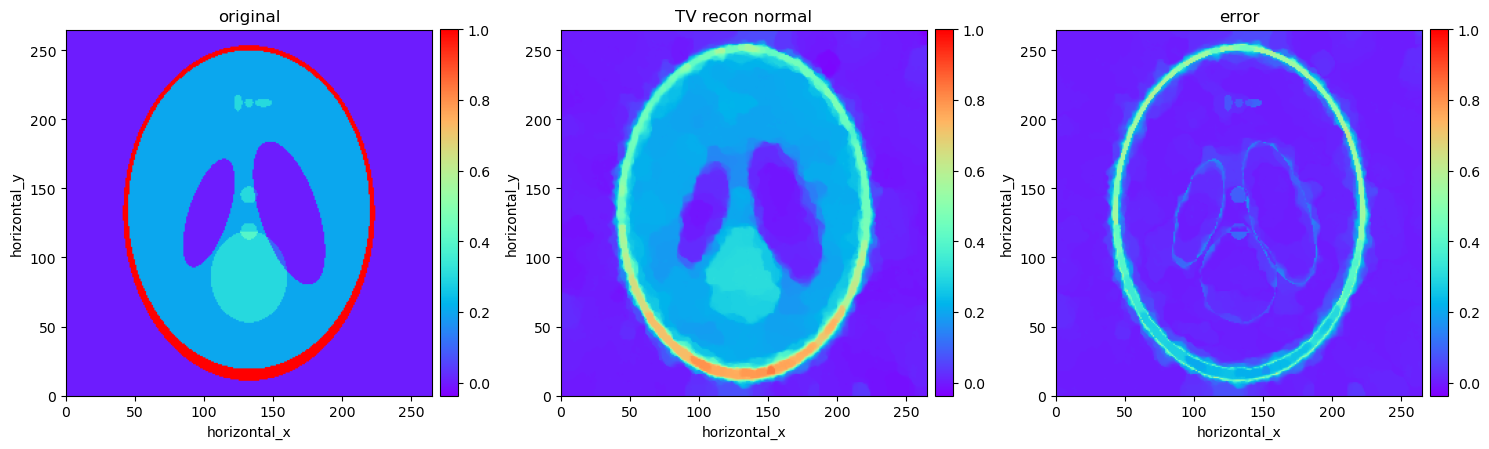

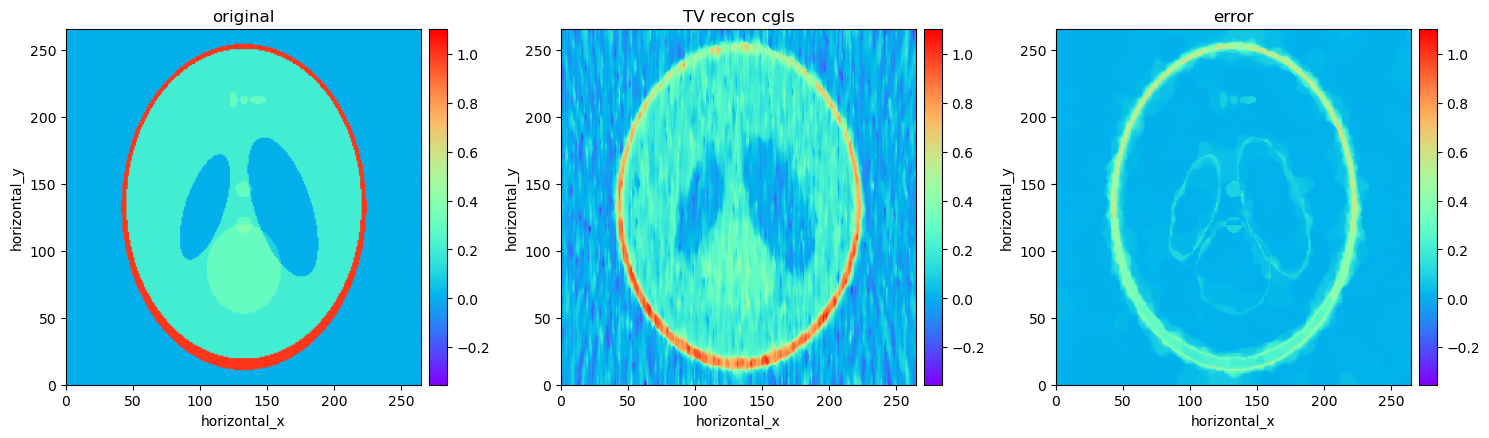

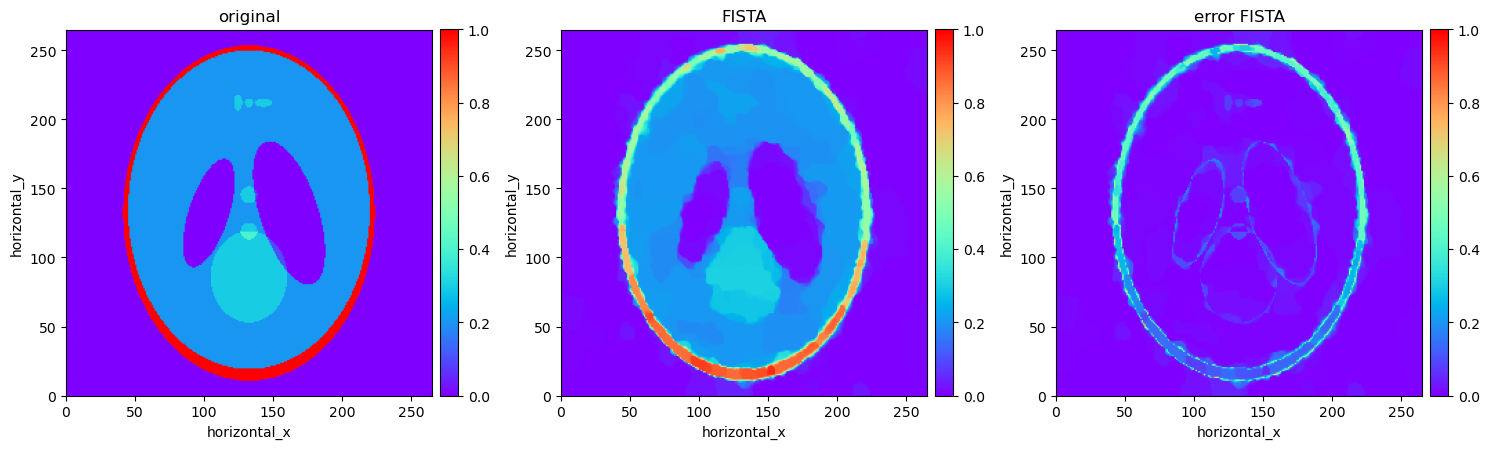

In [14]:
show2D([phantom, tv_normal_recon, (tv_normal_recon - phantom).abs()], 
       ['original', 'TV recon normal', 'error'], 
       cmap="rainbow", 
       num_cols = 3, 
       fix_range=True)


show2D([phantom, tv_cgls_recon, (tv_normal_recon - phantom).abs()], 
       ['original', 'TV recon cgls', 'error'], 
       cmap="rainbow", 
       num_cols = 3, 
       fix_range=True)

show2D([phantom, TV_reco, (phantom - TV_reco).abs()], ['original', 'FISTA', 'error FISTA'], 
       cmap ="rainbow", fix_range=True, num_cols=3)

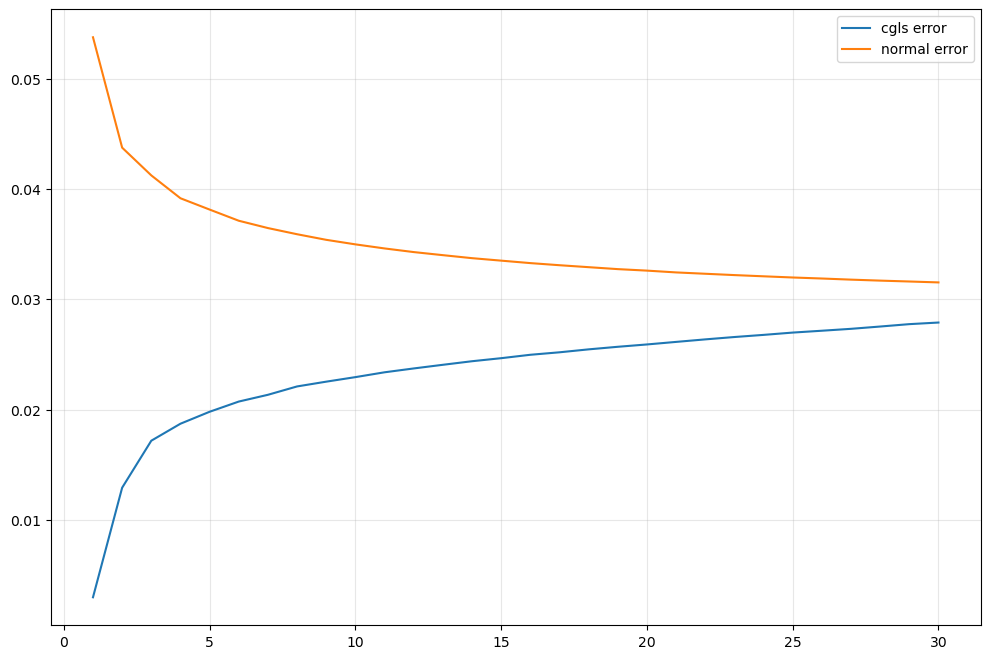

In [16]:
x = np.linspace(1, len(err_cgls_recon), len(err_cgls_recon))

plt.figure(figsize=(12,8))
plt.plot(x, err_cgls_recon, label='cgls error')
plt.plot(x, err_tv_normal_recon, label='normal error')
plt.legend()
plt.grid(alpha=0.3)

With one norm